# 🏏 IPL Match Analysis Dashboard

> **A complete Exploratory Data Analysis (EDA) of 13 IPL seasons (2008–2020)**

---

### 📌 Project Summary
This project analyzes **260,920 ball-by-ball delivery records** and **1,095 match records** from the Indian Premier League to uncover insights about team performance, player statistics, toss impact, and run-scoring trends.

### 🛠️ Tools & Libraries Used
| Library | Purpose |
|---|---|
| `NumPy` | Numerical operations |
| `Pandas` | Data loading, cleaning & manipulation |
| `Matplotlib` | Data visualization |
| `Seaborn` | Advanced statistical visualizations |

### 📂 Dataset
- **matches.csv** → 1,095 rows × 20 columns (one row per match)
- **deliveries.csv** → 2,60,920 rows × 17 columns (one row per ball bowled)

---

## 📦 Step 1 — Import Libraries & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set global plot style for consistent look
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
# Load both datasets
deliveries = pd.read_csv('deliveries.csv')
matches = pd.read_csv('matches.csv')

print(f'✅ deliveries.csv loaded → {deliveries.shape[0]:,} rows × {deliveries.shape[1]} columns')
print(f'✅ matches.csv loaded   → {matches.shape[0]:,} rows × {matches.shape[1]} columns')

✅ deliveries.csv loaded → 260,920 rows × 17 columns
✅ matches.csv loaded   → 1,095 rows × 20 columns


In [3]:
# Explore deliveries dataset
print('=== DELIVERIES DATASET ===')
deliveries.info()
deliveries.head(5)

=== DELIVERIES DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder    

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [4]:
# Explore matches dataset
print('=== MATCHES DATASET ===')
matches.info()
matches.head(5)

=== MATCHES DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   obj

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


---
## 🧹 Step 2 — Data Cleaning & Preprocessing

In [5]:
# Check missing values in matches dataset
print('Missing values in matches.csv:')
print('================================')
missing = matches.isnull().sum()
print(missing[missing > 0])

Missing values in matches.csv:
city                 51
player_of_match       5
winner                5
result_margin        19
target_runs           3
target_overs          3
method             1074
dtype: int64


In [6]:
# Drop rows where 'winner' is missing (no result matches)
before = len(matches)
matches.dropna(subset=['winner'], inplace=True)
after = len(matches)

print(f'Rows before: {before}')
print(f'Rows after : {after}')
print(f'Dropped    : {before - after} rows (no-result matches)')

Rows before: 1095
Rows after : 1090
Dropped    : 5 rows (no-result matches)


In [7]:
# Check all unique team names
print('Unique teams in IPL dataset:')
print('==============================')
for team in sorted(matches['team1'].unique()):
    print(f'  → {team}')

Unique teams in IPL dataset:
  → Chennai Super Kings
  → Deccan Chargers
  → Delhi Capitals
  → Delhi Daredevils
  → Gujarat Lions
  → Gujarat Titans
  → Kings XI Punjab
  → Kochi Tuskers Kerala
  → Kolkata Knight Riders
  → Lucknow Super Giants
  → Mumbai Indians
  → Pune Warriors
  → Punjab Kings
  → Rajasthan Royals
  → Rising Pune Supergiant
  → Rising Pune Supergiants
  → Royal Challengers Bangalore
  → Royal Challengers Bengaluru
  → Sunrisers Hyderabad


### ⚠️ Data Quality Issue Found!

After inspecting unique team names, we discovered **3 data inconsistencies**:

| Issue | Old Name | Correct Name |
|---|---|---|
| Spelling variation | `Rising Pune Supergiants` | `Rising Pune Supergiant` |
| Team rebranding | `Delhi Daredevils` | `Delhi Capitals` |
| Team rebranding | `Kings XI Punjab` | `Punjab Kings` |

**Fix:** Standardize all team names using a mapping dictionary.

In [8]:
# Standardize team names across the dataset
team_name_mapping = {
    'Rising Pune Supergiants' : 'Rising Pune Supergiant',
    'Delhi Daredevils'        : 'Delhi Capitals',
    'Kings XI Punjab'         : 'Punjab Kings',
}

for col in ['team1', 'team2', 'winner', 'toss_winner']:
    matches[col] = matches[col].replace(team_name_mapping)

# Rename 'id' to 'match_id' for easier merging
matches.rename(columns={'id': 'match_id'}, inplace=True)

print(f'✅ Team names standardized! Unique teams now: {matches["team1"].nunique()}')

✅ Team names standardized! Unique teams now: 16


---
## 📊 Step 3 — Visualizations

### Chart 1 — Top 10 Teams by Total Wins

C:\Users\umair\AppData\Local\Temp\ipykernel_6680\1786187648.py:17: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\umair\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


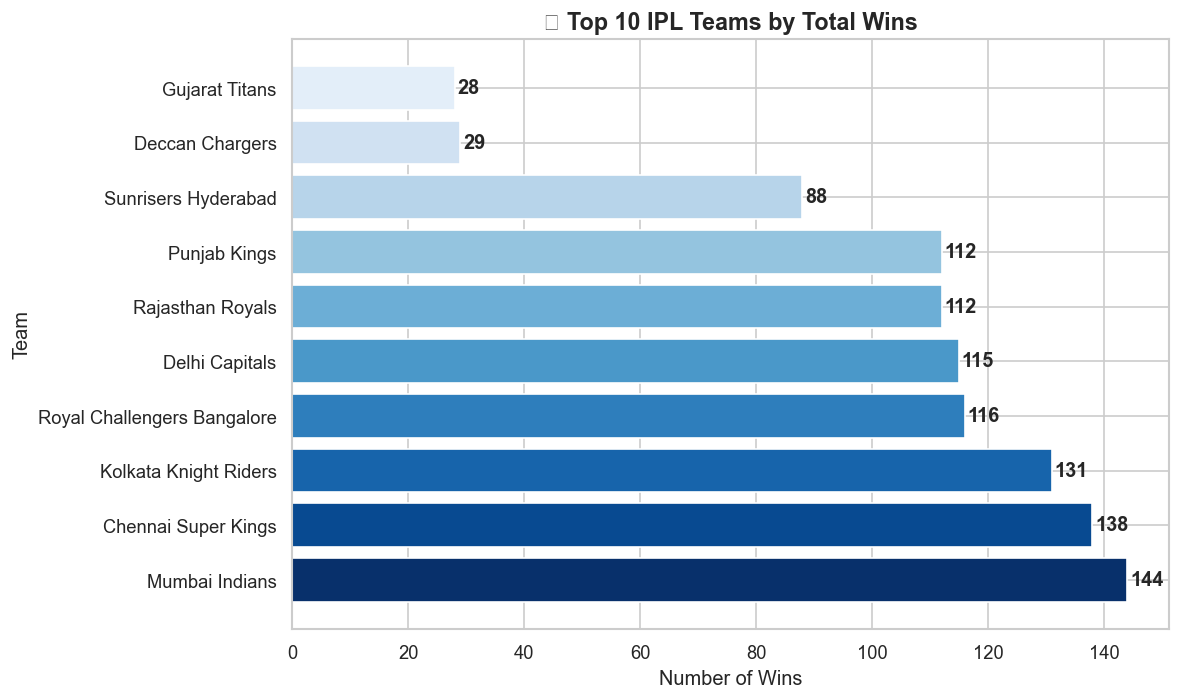


🔍 Insight: Mumbai Indians leads with 144 wins — the most successful IPL team!


In [9]:
win_counts = matches['winner'].value_counts()
top_ten = win_counts.head(10)

colors = plt.cm.Blues_r([i / 10 for i in range(10)])

plt.figure(figsize=(10, 6))
bars = plt.barh(top_ten.index, top_ten.values, color=colors, edgecolor='white')
plt.xlabel('Number of Wins', fontsize=12)
plt.ylabel('Team', fontsize=12)
plt.title('🏆 Top 10 IPL Teams by Total Wins', fontsize=14, fontweight='bold')

# Add value labels
for bar, value in zip(bars, top_ten.values):
    plt.text(value + 0.5, bar.get_y() + bar.get_height() / 2,
             str(value), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n🔍 Insight: {top_ten.index[0]} leads with {top_ten.values[0]} wins — the most successful IPL team!')

### Chart 2 — Does Winning the Toss Help Win the Match?

C:\Users\umair\AppData\Local\Temp\ipykernel_6680\248765458.py:18: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\umair\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


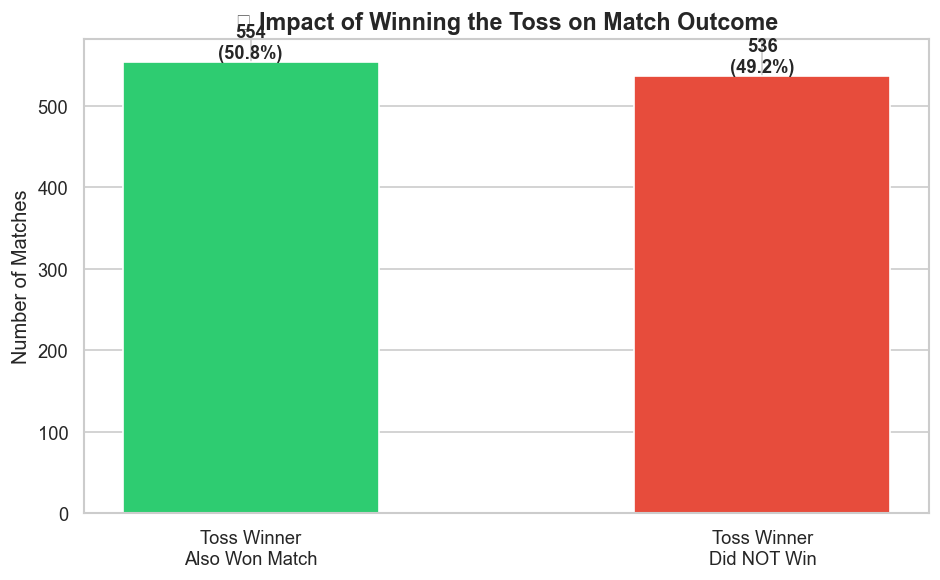


🔍 Insight: Toss winners go on to win only 50.8% of matches — toss advantage is minimal!


In [10]:
# Create boolean column: did toss winner also win the match?
matches['toss_win_match_win'] = matches['toss_winner'] == matches['winner']
toss_win_counts = matches['toss_win_match_win'].value_counts()

labels = ['Toss Winner\nAlso Won Match', 'Toss Winner\nDid NOT Win']
bar_colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, toss_win_counts.values, color=bar_colors, edgecolor='white', width=0.5)
plt.ylabel('Number of Matches', fontsize=12)
plt.title('🎯 Impact of Winning the Toss on Match Outcome', fontsize=14, fontweight='bold')

for bar, value in zip(bars, toss_win_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 5,
             f'{value}\n({value/sum(toss_win_counts.values)*100:.1f}%)',
             ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

win_pct = toss_win_counts.values[0] / sum(toss_win_counts.values) * 100
print(f'\n🔍 Insight: Toss winners go on to win only {win_pct:.1f}% of matches — toss advantage is minimal!')

### Chart 3 — Season-wise Total Runs Scored

C:\Users\umair\AppData\Local\Temp\ipykernel_6680\1421359970.py:24: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\umair\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


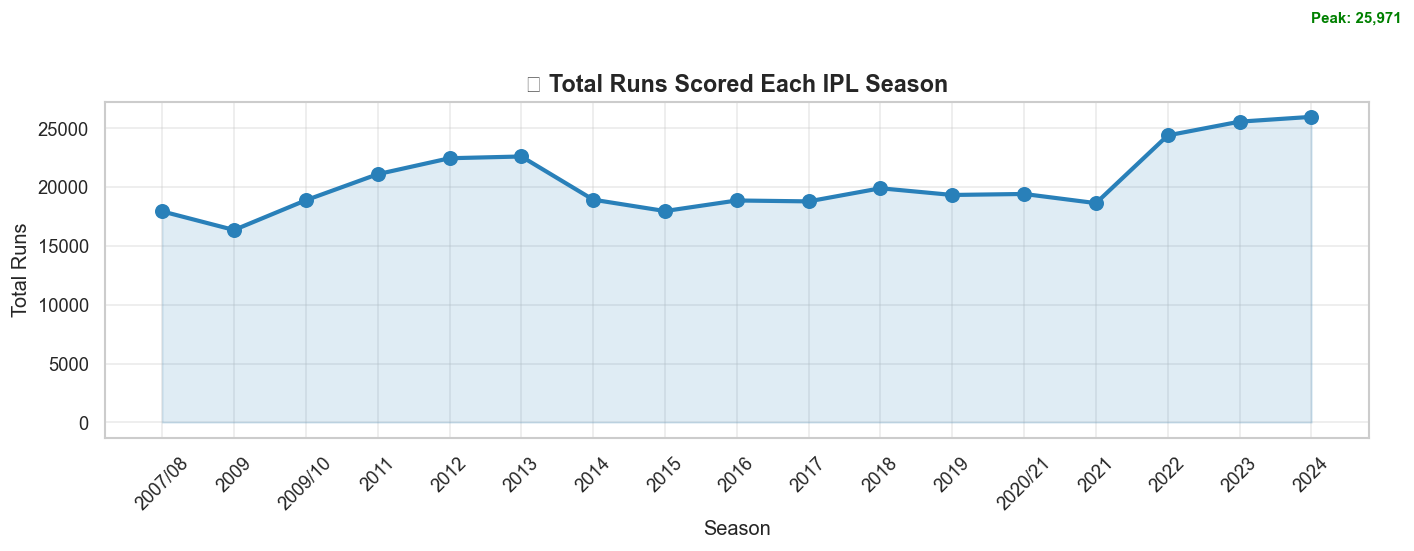


🔍 Insight: 2024 had the highest run-scoring season with 25,971 total runs!


In [11]:
# Merge deliveries with matches to get season info
merged_data = pd.merge(deliveries, matches[['match_id', 'season']], on='match_id', how='inner')
total_season_runs = merged_data.groupby('season')['total_runs'].sum()

plt.figure(figsize=(12, 5))
plt.plot(total_season_runs.index, total_season_runs.values,
         marker='o', color='#2980b9', linewidth=2.5, markersize=8)
plt.fill_between(total_season_runs.index, total_season_runs.values, alpha=0.15, color='#2980b9')

plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Runs', fontsize=12)
plt.title('📈 Total Runs Scored Each IPL Season', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.4)

# Annotate min and max seasons
max_season = total_season_runs.idxmax()
min_season = total_season_runs.idxmin()
plt.annotate(f'Peak: {total_season_runs.max():,}',
             xy=(max_season, total_season_runs.max()),
             xytext=(max_season, total_season_runs.max() + 8000),
             fontsize=9, color='green', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n🔍 Insight: {max_season} had the highest run-scoring season with {total_season_runs.max():,} total runs!')

### Chart 4 — Toss Decision: Bat or Field?

C:\Users\umair\AppData\Local\Temp\ipykernel_6680\3739147438.py:22: UserWarning: Glyph 127922 (\N{GAME DIE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\umair\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127922 (\N{GAME DIE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


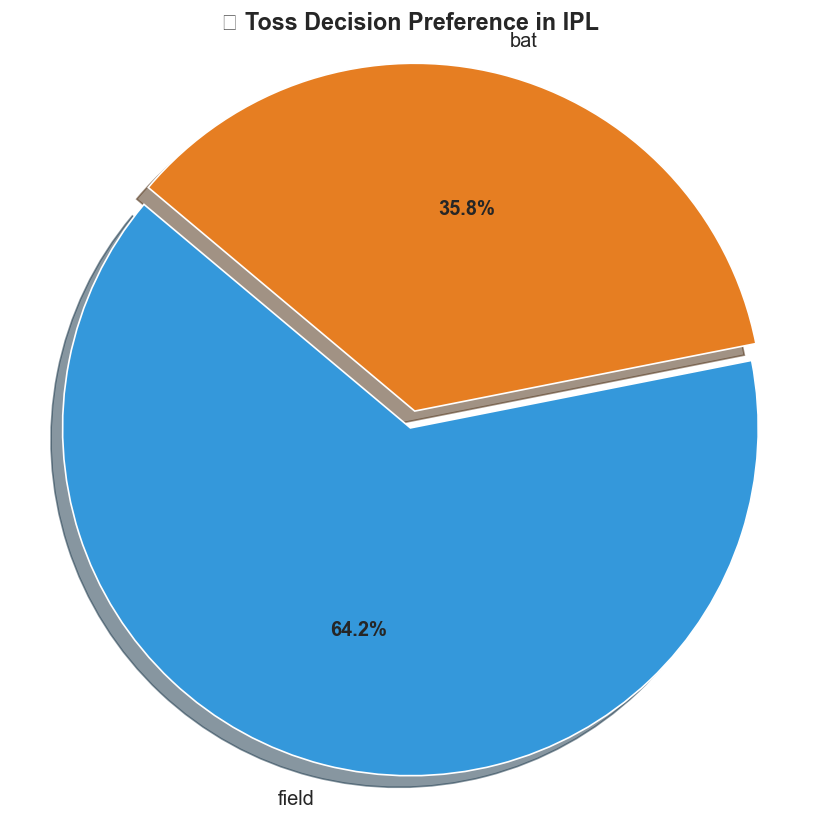


🔍 Insight: 64.2% of captains choose to "field" first after winning the toss!


In [12]:
toss_decision_counts = matches['toss_decision'].value_counts()
labels = toss_decision_counts.index
explode = (0.05, 0)
colors = ['#3498db', '#e67e22']

plt.figure(figsize=(7, 7))
wedges, texts, autotexts = plt.pie(
    toss_decision_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    shadow=True,
    colors=colors,
    textprops={'fontsize': 12}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')

plt.title('🎲 Toss Decision Preference in IPL', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

dominant = toss_decision_counts.index[0]
pct = toss_decision_counts.values[0] / toss_decision_counts.sum() * 100
print(f'\n🔍 Insight: {pct:.1f}% of captains choose to "{dominant}" first after winning the toss!')

### Chart 5 — Distribution of Win Margins (by Runs)

C:\Users\umair\AppData\Local\Temp\ipykernel_6680\579922521.py:12: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\umair\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


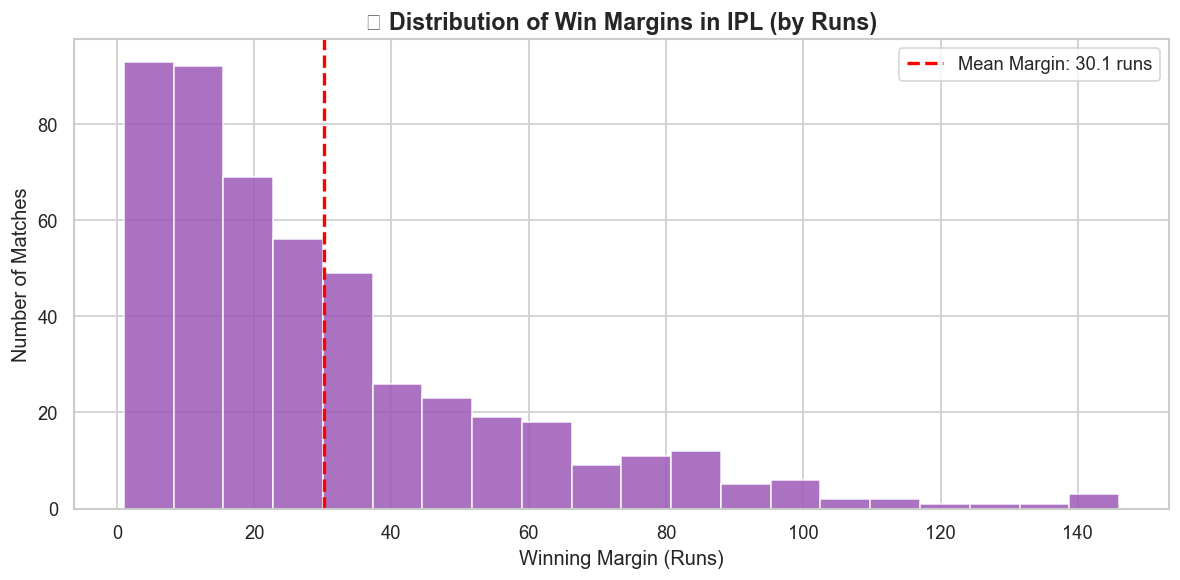


🔍 Insight: Average win margin is 30.1 runs.
   238 out of 498 matches (47.8%) were won by ≤20 runs — very competitive!


In [13]:
runs_wins = matches[matches['result'] == 'runs']
mean_margin = runs_wins['result_margin'].mean()

plt.figure(figsize=(10, 5))
plt.hist(runs_wins['result_margin'], bins=20, color='#9b59b6', edgecolor='white', alpha=0.85)
plt.axvline(mean_margin, color='red', linestyle='--', linewidth=2,
            label=f'Mean Margin: {mean_margin:.1f} runs')
plt.xlabel('Winning Margin (Runs)', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.title('📊 Distribution of Win Margins in IPL (by Runs)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

close_games = len(runs_wins[runs_wins['result_margin'] <= 20])
print(f'\n🔍 Insight: Average win margin is {mean_margin:.1f} runs.')
print(f'   {close_games} out of {len(runs_wins)} matches ({close_games/len(runs_wins)*100:.1f}%) were won by ≤20 runs — very competitive!')

### Chart 6 — Top 15 Run Scorers in IPL History

C:\Users\umair\AppData\Local\Temp\ipykernel_6680\1176674424.py:22: UserWarning: Glyph 127951 (\N{CRICKET BAT AND BALL}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\umair\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127951 (\N{CRICKET BAT AND BALL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


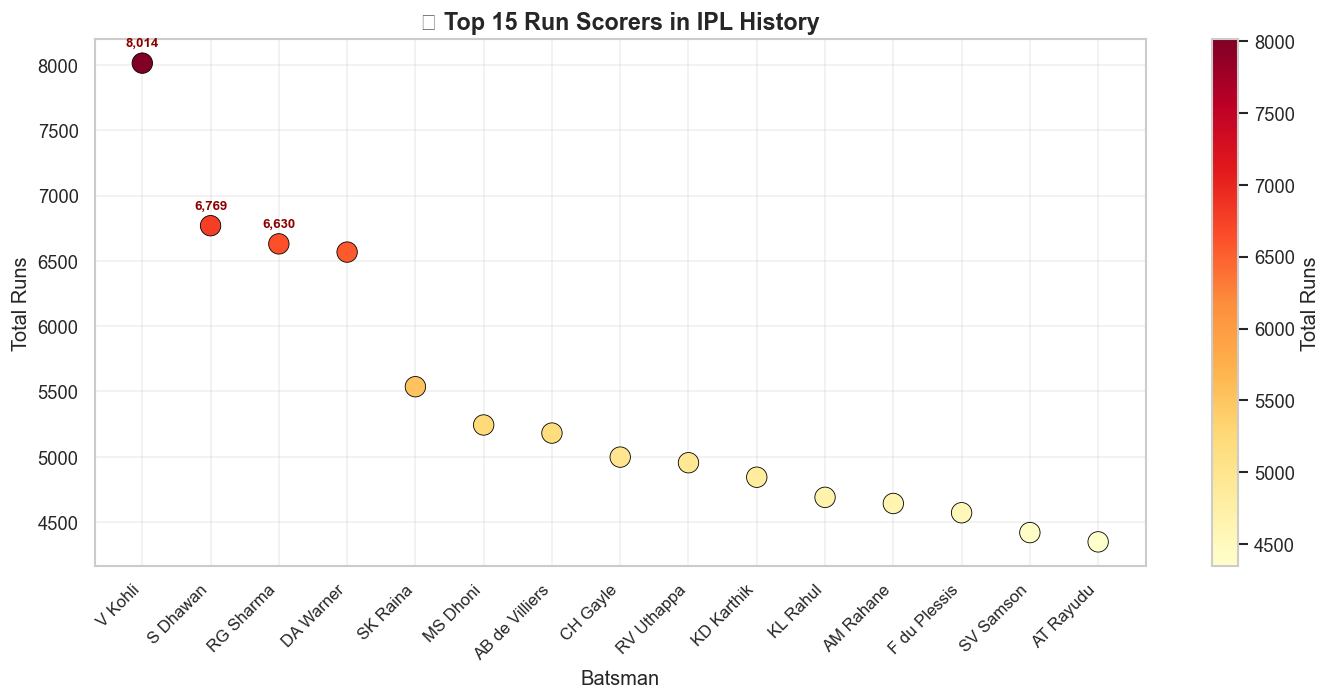


🔍 Insight: V Kohli is the all-time leading run scorer with 8,014 runs!


In [14]:
top_batsmen = (deliveries.groupby('batter')['batsman_runs']
               .sum().sort_values(ascending=False).head(15))

plt.figure(figsize=(12, 6))
scatter = plt.scatter(range(len(top_batsmen)), top_batsmen.values,
                      s=150, c=top_batsmen.values, cmap='YlOrRd', edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Total Runs')

plt.xticks(range(len(top_batsmen)), top_batsmen.index, rotation=45, ha='right', fontsize=10)
plt.xlabel('Batsman', fontsize=12)
plt.ylabel('Total Runs', fontsize=12)
plt.title('🏏 Top 15 Run Scorers in IPL History', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Annotate top 3
for i in range(3):
    plt.annotate(f'{top_batsmen.values[i]:,}',
                 (i, top_batsmen.values[i]),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=8, fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()

print(f'\n🔍 Insight: {top_batsmen.index[0]} is the all-time leading run scorer with {top_batsmen.values[0]:,} runs!')

### Chart 7 — Top 10 Bowlers: Wickets per Season (Seaborn Heatmap)

C:\Users\umair\AppData\Local\Temp\ipykernel_6680\297668299.py:26: UserWarning: Glyph 127923 (\N{BOWLING}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\umair\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127923 (\N{BOWLING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


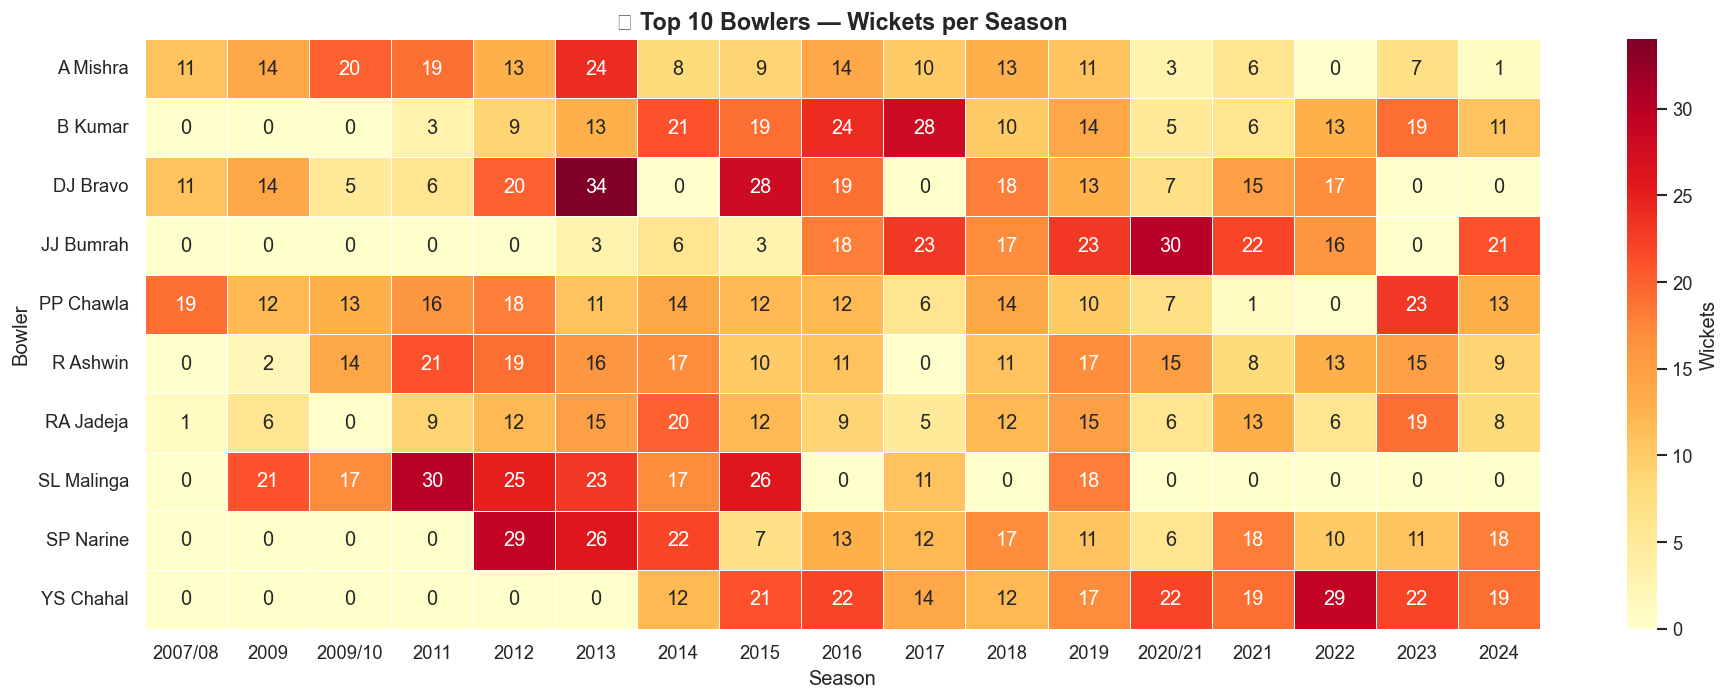


🔍 Insight: YS Chahal is the most consistent wicket-taker across all seasons!


In [15]:
# Filter actual wickets only
actual_wickets = deliveries[deliveries['is_wicket'] == 1]

# Merge with season info
actual_wickets_merged = pd.merge(
    actual_wickets, matches[['match_id', 'season']], on='match_id'
)

# Get top 10 bowlers by total wickets
top_bowlers = (actual_wickets_merged.groupby('bowler')['is_wicket']
               .sum().sort_values(ascending=False).head(10).index)

# Filter and pivot
top_wickets = actual_wickets_merged[actual_wickets_merged['bowler'].isin(top_bowlers)]
pivot = top_wickets.pivot_table(
    index='bowler', columns='season', values='is_wicket', aggfunc='sum'
).fillna(0)

# Plot heatmap
plt.figure(figsize=(16, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Wickets'})
plt.title('🎳 Top 10 Bowlers — Wickets per Season', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Bowler', fontsize=12)
plt.tight_layout()
plt.show()

top_bowler = pivot.sum(axis=1).idxmax()
print(f'\n🔍 Insight: {top_bowler} is the most consistent wicket-taker across all seasons!')

---
## 🖥️ Step 4 — Final IPL Dashboard

> All key visualizations combined into one professional dashboard

C:\Users\umair\AppData\Local\Temp\ipykernel_6680\1011939726.py:44: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\umair\AppData\Local\Temp\ipykernel_6680\1011939726.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\umair\AppData\Local\Temp\ipykernel_6680\1011939726.py:44: UserWarning: Glyph 127922 (\N{GAME DIE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\umair\AppData\Local\Temp\ipykernel_6680\1011939726.py:44: UserWarning: Glyph 127951 (\N{CRICKET BAT AND BALL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\umair\AppData\Local\Temp\ipykernel_6680\1011939726.py:45: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.savefig('IPL_Dashboard.png', dpi=150, bbox_inches='tight')
C:\Users\umair\AppData\Local\Temp\ipykernel_6680\1011939726.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Ar

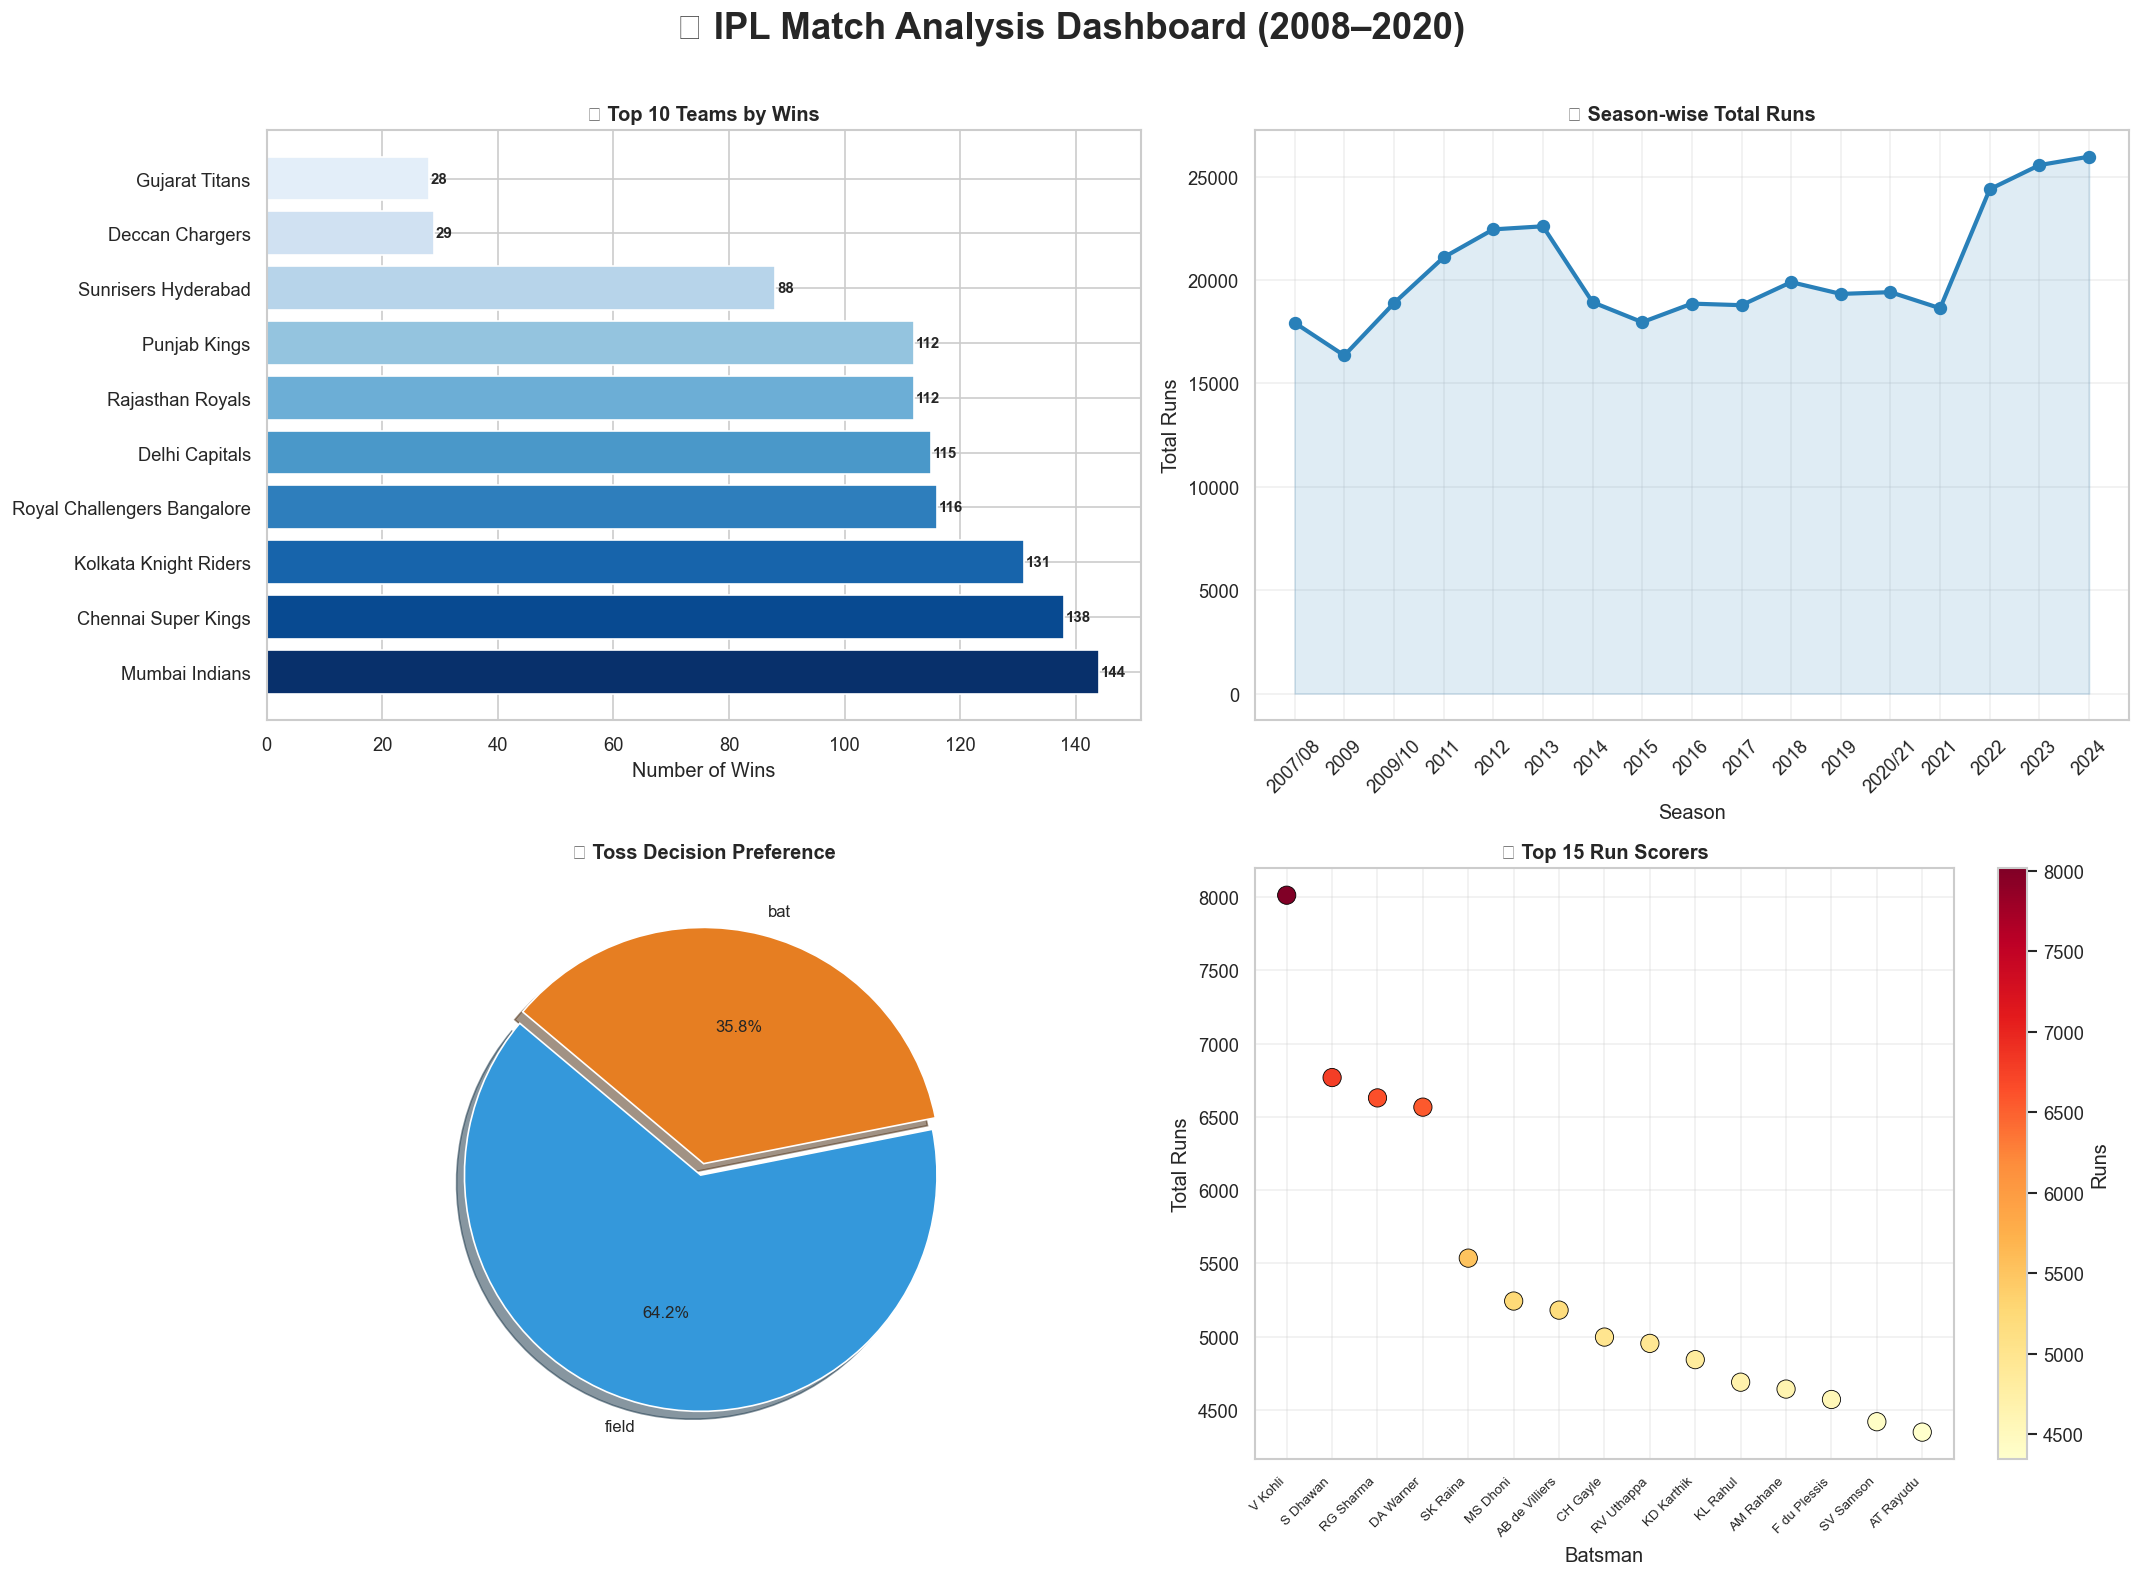

✅ Dashboard saved as IPL_Dashboard.png!


In [16]:
fig, axs = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('🏏 IPL Match Analysis Dashboard (2008–2020)',
             fontsize=22, fontweight='bold', y=1.01)

# ── PLOT 1: Top 10 Teams by Wins ──
colors_bar = plt.cm.Blues_r([i / 10 for i in range(10)])
axs[0, 0].barh(top_ten.index, top_ten.values, color=colors_bar, edgecolor='white')
axs[0, 0].set_xlabel('Number of Wins')
axs[0, 0].set_title('🏆 Top 10 Teams by Wins', fontweight='bold')
for i, v in enumerate(top_ten.values):
    axs[0, 0].text(v + 0.3, i, str(v), va='center', fontsize=9, fontweight='bold')

# ── PLOT 2: Season-wise Total Runs ──
axs[0, 1].plot(total_season_runs.index, total_season_runs.values,
               marker='o', color='#2980b9', linewidth=2.5, markersize=7)
axs[0, 1].fill_between(total_season_runs.index, total_season_runs.values, alpha=0.15, color='#2980b9')
axs[0, 1].set_xlabel('Season')
axs[0, 1].set_ylabel('Total Runs')
axs[0, 1].set_title('📈 Season-wise Total Runs', fontweight='bold')
axs[0, 1].tick_params(axis='x', rotation=45)
axs[0, 1].grid(True, alpha=0.3)

# ── PLOT 3: Toss Decision Pie ──
toss_labels = toss_decision_counts.index
axs[1, 0].pie(toss_decision_counts.values, labels=toss_labels,
              autopct='%1.1f%%', startangle=140,
              explode=(0.05, 0), shadow=True,
              colors=['#3498db', '#e67e22'],
              textprops={'fontsize': 10})
axs[1, 0].set_title('🎲 Toss Decision Preference', fontweight='bold')

# ── PLOT 4: Top 15 Batsmen Scatter ──
scatter = axs[1, 1].scatter(range(len(top_batsmen)), top_batsmen.values,
                             s=120, c=top_batsmen.values, cmap='YlOrRd',
                             edgecolors='black', linewidth=0.5)
axs[1, 1].set_xticks(range(len(top_batsmen)))
axs[1, 1].set_xticklabels(top_batsmen.index, rotation=45, ha='right', fontsize=8)
axs[1, 1].set_xlabel('Batsman')
axs[1, 1].set_ylabel('Total Runs')
axs[1, 1].set_title('🏏 Top 15 Run Scorers', fontweight='bold')
axs[1, 1].grid(True, alpha=0.3)
fig.colorbar(scatter, ax=axs[1, 1], label='Runs')

plt.tight_layout()
plt.savefig('IPL_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved as IPL_Dashboard.png!')

---
## 💡 Key Insights Summary

| # | Insight |
|---|---|
| 1 | 🏆 **Mumbai Indians** are the most successful IPL team by total wins |
| 2 | 🎯 Winning the toss helps win only **~50%** of the time — team quality matters more |
| 3 | 📈 Run-scoring has **increased** season over season, reflecting T20 evolution |
| 4 | 🎲 Most captains prefer **fielding first** after winning the toss |
| 5 | 📊 Most IPL matches won by runs have a margin of **10–30 runs** — very competitive |
| 6 | 🏏 **Virat Kohli** is the all-time leading run scorer in IPL history |
| 7 | 🎳 **YS Chahal** is the most consistent wicket-taker across multiple seasons |

---

## 🙏 Thank You!

> *This project was built as part of my Data Science learning journey using Python, Pandas, Matplotlib and Seaborn.*
> 
> **Connect with me on LinkedIn!** 🔗